In [1]:
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from matplotlib.lines import Line2D
import math
import pandas as pd
from datetime import datetime, timedelta

from ebm.params import *

%load_ext autoreload

## ESM model results

In [2]:
# Open dataset
ds_pi =xr.open_dataset('../data/tas_Amon_MPI-ESM1-2-LR_piControl_r1i1p1f1_g025_185001-284912.nc') 
ds1  = xr.open_dataset('../data/tas_Amon_MPI-ESM1-2-LR_historical-ssp245_r25i1p1f1_g025_185001-210012.nc')
ds2  = xr.open_dataset('../data/tas_Amon_MPI-ESM1-2-LR_historical-ssp245_r1i1p1f1_g025_185001-210012.nc')

# Compute weights for weighing by area (so poles aren't overrepresented)
weights = np.cos(np.deg2rad(ds1.lat))

# Compute global mean temp
global_mean1   = ds1.tas.weighted(weights).mean(dim=['lat', 'lon']).resample(time='YS').mean()
global_mean2   = ds2.tas.weighted(weights).mean(dim=['lat', 'lon']).resample(time='YS').mean()
global_mean_pi = ds_pi.tas.weighted(weights).mean(dim=['lat', 'lon']).resample(time='YS').mean().sel(time=slice('1850-01-01', '2100-01-01'))

/tmp/ipykernel_42823/1847659009.py:2: SerializationWarning: Unable to decode time axis into full numpy.datetime64[ns] objects, continuing using cftime.datetime objects instead, reason: dates out of range. To silence this warning use a coarser resolution 'time_unit' or specify 'use_cftime=True'.
  ds_pi =xr.open_dataset('../data/tas_Amon_MPI-ESM1-2-LR_piControl_r1i1p1f1_g025_185001-284912.nc')
/tmp/ipykernel_42823/1847659009.py:2: SerializationWarning: Unable to decode time axis into full numpy.datetime64[ns] objects, continuing using cftime.datetime objects instead, reason: dates out of range. To silence this warning use a coarser resolution 'time_unit' or specify 'use_cftime=True'.
  ds_pi =xr.open_dataset('../data/tas_Amon_MPI-ESM1-2-LR_piControl_r1i1p1f1_g025_185001-284912.nc')
/tmp/ipykernel_42823/1847659009.py:2: SerializationWarning: Unable to decode time axis into full numpy.datetime64[ns] objects, continuing using cftime.datetime objects instead, reason: dates out of range. To 

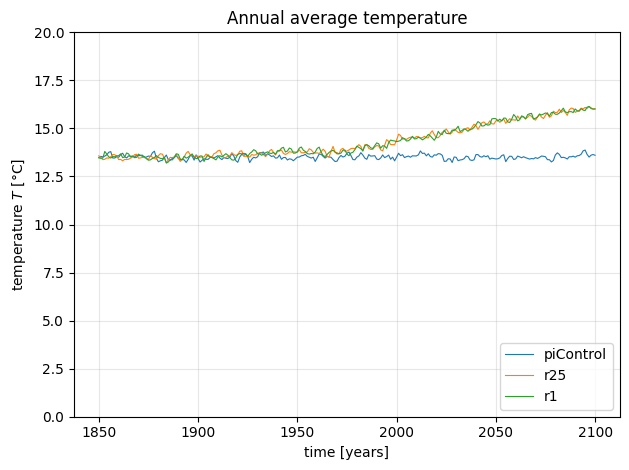

In [3]:
# pre-industrial control
plt.plot(global_mean_pi.time.dt.year, global_mean_pi-273.15, '-', lw=0.8, label='piControl')
# ESM (r25)
plt.plot(global_mean1.time.dt.year, global_mean1-273.15, '-', lw=0.8, label='r25')
# ESM (r1)
plt.plot(global_mean2.time.dt.year, global_mean2-273.15, '-', lw=0.8, label='r1')

plt.title('Annual average temperature')
plt.xlabel('time [years]')
plt.ylabel(r'temperature $T$ [°C]')
plt.grid(True, alpha=0.3)
plt.legend(loc='lower right')
plt.tight_layout()
plt.ylim(0, 20)

plt.savefig('plots/hist-sim.png')
plt.savefig('plots/hist-sim.pdf')
plt.show()

## 0D EBM model

$ SW = \frac{S_0}{4} (1-\alpha)$

$ LW = \epsilon \sigma T_{abs}^4 $

$ T_{abs}(t=t_i+1) = T_{abs}(t_i) + \Delta t \frac{SW-LW}{c_e} $ 

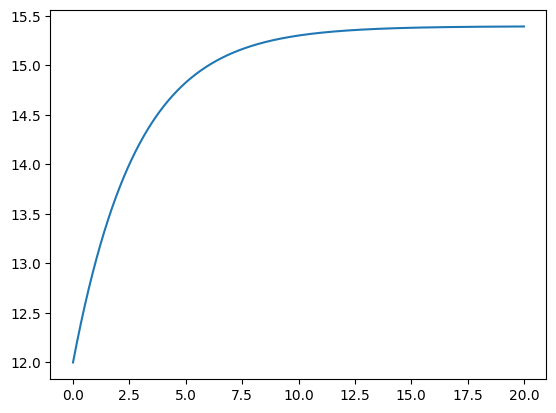

In [4]:
%autoreload
from ebm.model import run_model

# test run
temp, time = run_model()

plt.plot(time, temp)
plt.show()

### Unchanged EBM started in 1981

In [5]:
start_year = 1980
# start_year = 1850
T_init = global_mean1.sel(time=str(start_year)).values[0]

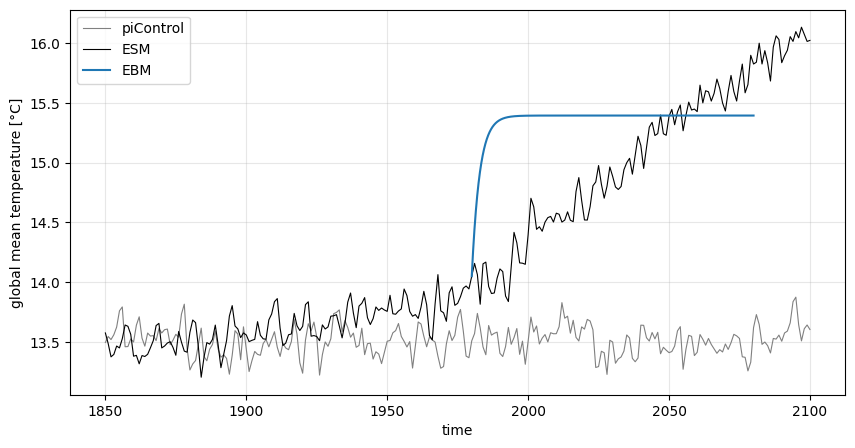

In [ ]:
%autoreload
from ebm.model import run_model
from sutils import plot_ebm_vs_esm

temp, time = run_model(T_ini=T_init, maxtime=100*secyear)

plot_ebm_vs_esm(
    time_ebm=time+start_year,
    temp_ebm=temp,
    time_esm=global_mean1.time.dt.year,
    temp_esm=global_mean1-273.15,
    temp_control=global_mean_pi-273.15
    )

plt.savefig('plots/ebm-vs-esm.png', bbox_inches='tight')
plt.savefig('plots/ebm-vs-esm.pdf', bbox_inches='tight')
# plt.show()

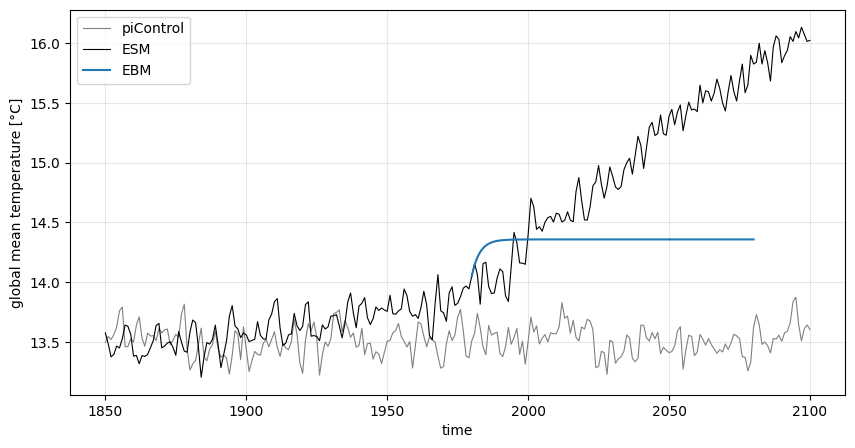

In [7]:
%autoreload
from ebm.model import run_model
from utils import plot_ebm_vs_esm

temp, time = run_model(T_ini=T_init, maxtime=100*secyear, alpha=0.31)

plot_ebm_vs_esm(
    time_ebm=time+start_year,
    temp_ebm=temp,
    time_esm=global_mean1.time.dt.year,
    temp_esm=global_mean1-273.15,
    temp_control=global_mean_pi-273.15
    )